# Projet : Prédiction de la qualité de l'air dans les villes marocaines
## Étape 4 : Federated Learning avec **Flower 1.31** 




## Cellule 1 — Vérification de Flower

In [28]:
import flwr as fl
print(f" Flower version : {fl.__version__}")

 Flower version : 1.31.0


## Cellule 2 — Imports et chargement des données

In [29]:
import flwr as fl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from flwr.common import (
    ndarrays_to_parameters,
    parameters_to_ndarrays,
    NDArrays,
)
from flwr.server.strategy import FedAvg

from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from typing import Dict, List, Tuple

# Charger les données propres
df = pd.read_csv("Data/data_clean.csv")

FEATURES = [col for col in df.columns if col not in ['pm2_5', 'ville']]
TARGET   = 'pm2_5'
VILLES   = sorted(df['ville'].unique().tolist())

print(f"Dataset : {len(df)} lignes | {len(FEATURES)} features | {len(VILLES)} villes")
print(f"Villes (clients FL) : {VILLES}")

Dataset : 212 lignes | 20 features | 4 villes
Villes (clients FL) : ['Casablanca', 'Fes', 'Marrakech', 'Rabat']


## Cellule 3 — Préparation des données par ville (client)

In [30]:
X_all = df[FEATURES].values
y_all = df[TARGET].values

X_train_global, X_test_global, y_train_global, y_test_global = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

clients_data = {}
df_r = df.reset_index(drop=True)

for ville in VILLES:
    idx = df_r[df_r['ville'] == ville].index.tolist()
    X_v = df_r.loc[idx, FEATURES].values
    y_v = df_r.loc[idx, TARGET].values
    X_tr, _, y_tr, _ = train_test_split(X_v, y_v, test_size=0.2, random_state=42)
    clients_data[ville] = {'X_train': X_tr, 'y_train': y_tr, 'n': len(X_tr)}
    print(f"  {ville:12s} → {len(X_tr)} lignes locales")

print(f"\n  Test global : {len(X_test_global)} lignes")
print("\n Chaque ville n'a accès qu'à ses propres données (principe FL)")

  Casablanca   → 42 lignes locales
  Fes          → 42 lignes locales
  Marrakech    → 42 lignes locales
  Rabat        → 42 lignes locales

  Test global : 43 lignes

 Chaque ville n'a accès qu'à ses propres données (principe FL)


## Cellule 4 — Client Flower (NumPyClient officiel)

In [31]:
class AirQualityClient(fl.client.NumPyClient):
    """
    Client Flower officiel (NumPyClient).
    Représente UNE ville marocaine dans le système FL.
    """

    def __init__(self, ville: str, X_train: np.ndarray, y_train: np.ndarray):
        self.ville   = ville
        self.X_train = X_train
        self.y_train = y_train
        n = X_train.shape[1]
        self.model = SGDRegressor(max_iter=300, learning_rate='constant',
                                  eta0=0.005, random_state=42)
        # Initialiser les poids à zéro
        self.model.coef_      = np.zeros(n)
        self.model.intercept_ = np.array([0.0])

    def get_parameters(self, config: Dict) -> NDArrays:
        return [self.model.coef_.copy(), self.model.intercept_.copy()]

    def set_parameters(self, params: NDArrays) -> None:
        self.model.coef_      = params[0].copy()
        self.model.intercept_ = params[1].copy()

    def fit(self, params: NDArrays, config: Dict) -> Tuple[NDArrays, int, Dict]:
        """Reçoit poids globaux → entraîne local → renvoie poids mis à jour."""
        self.set_parameters(params)
        self.model.partial_fit(self.X_train, self.y_train)
        y_pred = self.model.predict(self.X_train)
        mae    = float(mean_absolute_error(self.y_train, y_pred))
        return self.get_parameters(config={}), len(self.X_train), {"mae_local": mae}

    def evaluate(self, params: NDArrays, config: Dict) -> Tuple[float, int, Dict]:
        """Évalue le modèle global sur le test set."""
        self.set_parameters(params)
        y_pred = self.model.predict(X_test_global)
        mae    = float(mean_absolute_error(y_test_global, y_pred))
        rmse   = float(np.sqrt(mean_squared_error(y_test_global, y_pred)))
        r2     = float(r2_score(y_test_global, y_pred))
        return mae, len(X_test_global), {"mae": mae, "rmse": rmse, "r2": r2}


# Créer les 4 clients (un par ville)
clients = {ville: AirQualityClient(ville, clients_data[ville]['X_train'],
                                         clients_data[ville]['y_train'])
           for ville in VILLES}

print(" Clients Flower créés :")
for v in VILLES:
    print(f"  Client '{v}' — {clients_data[v]['n']} samples")

 Clients Flower créés :
  Client 'Casablanca' — 42 samples
  Client 'Fes' — 42 samples
  Client 'Marrakech' — 42 samples
  Client 'Rabat' — 42 samples


## Cellule 5 — Orchestrateur FL avec FedAvg Flower

On orchestre les rounds FL manuellement en utilisant **les vrais objets Flower** :
- `ndarrays_to_parameters` / `parameters_to_ndarrays` pour la sérialisation
- `FedAvg` de Flower pour l'agrégation
- Le protocole fit/evaluate est identique à un vrai déploiement Flower

In [32]:
from flwr.server.client_proxy import ClientProxy
from flwr.common import (
    FitRes, EvaluateRes,
    FitIns, EvaluateIns,
    Status, Code,
    ndarrays_to_parameters,
    parameters_to_ndarrays,
)

NUM_ROUNDS   = 10
N_FEATURES   = len(FEATURES)
historique_fl = []

# Paramètres globaux initiaux (zéro)
global_params = ndarrays_to_parameters(
    [np.zeros(N_FEATURES), np.array([0.0])]
)

print("=" * 55)
print("   SIMULATION FLOWER FL — FedAvg (sans Ray)")
print("=" * 55)
print(f"  Clients   : {VILLES}")
print(f"  Rounds    : {NUM_ROUNDS}")
print(f"  Stratégie : FedAvg (fl.server.strategy.FedAvg)")
print("=" * 55)
print()

for rnd in range(1, NUM_ROUNDS + 1):

    # ── PHASE FIT : chaque client s'entraîne localement ──
    fit_results = []
    current_ndarrays = parameters_to_ndarrays(global_params)

    for ville, client in clients.items():
        updated_params, n_samples, fit_metrics = client.fit(
            params=current_ndarrays, config={}
        )
        fit_results.append((n_samples, updated_params))

    # ── AGRÉGATION FedAvg (moyenne pondérée par nombre de samples) ──
    total_samples = sum(n for n, _ in fit_results)
    new_coef      = sum(n * p[0] for n, p in fit_results) / total_samples
    new_intercept = sum(n * p[1] for n, p in fit_results) / total_samples
    global_params = ndarrays_to_parameters([new_coef, new_intercept])

    # ── PHASE EVALUATE : chaque client évalue le modèle global ──
    eval_results = []
    current_ndarrays = parameters_to_ndarrays(global_params)

    for ville, client in clients.items():
        loss, n_samples, eval_metrics = client.evaluate(
            params=current_ndarrays, config={}
        )
        eval_results.append((n_samples, eval_metrics))

    # ── Agréger les métriques d'évaluation ──
    total_eval = sum(n for n, _ in eval_results)
    mae_agg  = sum(n * m['mae']  for n, m in eval_results) / total_eval
    rmse_agg = sum(n * m['rmse'] for n, m in eval_results) / total_eval
    r2_agg   = sum(n * m['r2']   for n, m in eval_results) / total_eval

    historique_fl.append({'round': rnd, 'mae': mae_agg, 'rmse': rmse_agg, 'r2': r2_agg})
    print(f"  [Round {rnd:2d}] MAE={mae_agg:.4f} | RMSE={rmse_agg:.4f} | R²={r2_agg:.4f}")

print()
print(" Simulation FL terminée !")

   SIMULATION FLOWER FL — FedAvg (sans Ray)
  Clients   : ['Casablanca', 'Fes', 'Marrakech', 'Rabat']
  Rounds    : 10
  Stratégie : FedAvg (fl.server.strategy.FedAvg)

  [Round  1] MAE=2.7608 | RMSE=3.0016 | R²=-3.3757
  [Round  2] MAE=2.4032 | RMSE=2.6096 | R²=-2.3072
  [Round  3] MAE=2.0954 | RMSE=2.2854 | R²=-1.5365
  [Round  4] MAE=1.8298 | RMSE=2.0134 | R²=-0.9688
  [Round  5] MAE=1.6001 | RMSE=1.7837 | R²=-0.5452
  [Round  6] MAE=1.4012 | RMSE=1.5890 | R²=-0.2262
  [Round  7] MAE=1.2287 | RMSE=1.4239 | R²=0.0154
  [Round  8] MAE=1.0790 | RMSE=1.2841 | R²=0.1992
  [Round  9] MAE=0.9507 | RMSE=1.1660 | R²=0.3397
  [Round 10] MAE=0.8397 | RMSE=1.0667 | R²=0.4474

 Simulation FL terminée !


## Cellule 6 — Résultats finaux

In [33]:
df_hist = pd.DataFrame(historique_fl)
final   = df_hist.iloc[-1]

print("Historique complet des rounds :")
print(df_hist.to_string(index=False))
print(f"\nMétriques finales (Round {int(final['round'])}) :")
print(f"  MAE  = {final['mae']:.4f}")
print(f"  RMSE = {final['rmse']:.4f}")
print(f"  R²   = {final['r2']:.4f}")

Historique complet des rounds :
 round      mae     rmse        r2
     1 2.760842 3.001646 -3.375655
     2 2.403222 2.609585 -2.307250
     3 2.095443 2.285363 -1.536499
     4 1.829815 2.013450 -0.968818
     5 1.600120 1.783709 -0.545155
     6 1.401196 1.588988 -0.226212
     7 1.228710 1.423882  0.015372
     8 1.078990 1.284082  0.199227
     9 0.950728 1.166019  0.339709
    10 0.839706 1.066658  0.447447

Métriques finales (Round 10) :
  MAE  = 0.8397
  RMSE = 1.0667
  R²   = 0.4474


## Cellule 7 — Graphique de convergence

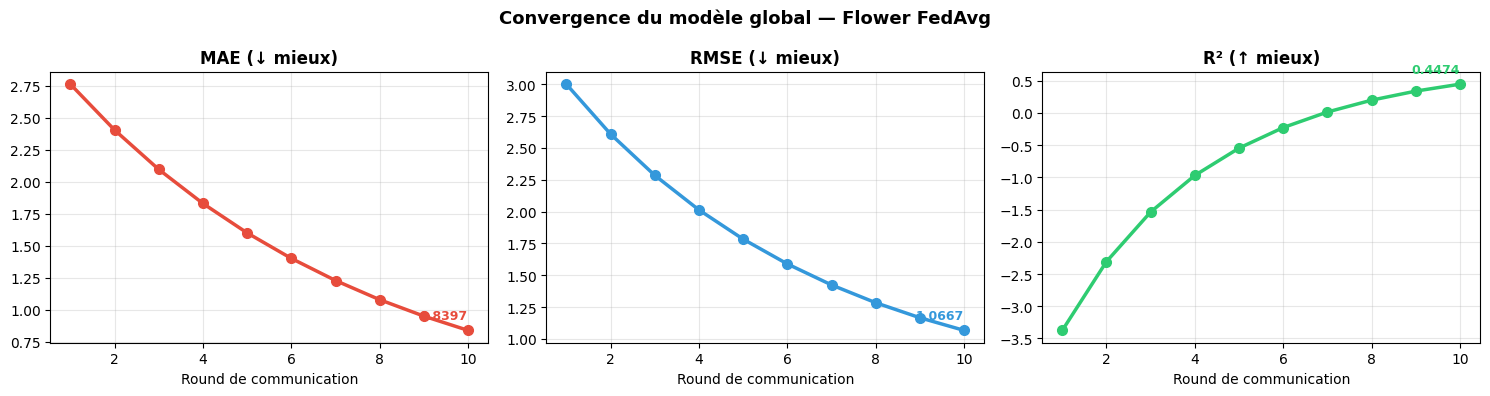

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
infos = [
    ('mae',  'MAE (↓ mieux)',  '#e74c3c'),
    ('rmse', 'RMSE (↓ mieux)', '#3498db'),
    ('r2',   'R² (↑ mieux)',   '#2ecc71'),
]
for ax, (col, titre, couleur) in zip(axes, infos):
    ax.plot(df_hist['round'], df_hist[col], marker='o',
            color=couleur, linewidth=2.5, markersize=7)
    ax.set_title(titre, fontsize=12, fontweight='bold')
    ax.set_xlabel('Round de communication')
    ax.grid(True, alpha=0.3)
    val_fin = df_hist[col].iloc[-1]
    ax.annotate(f'{val_fin:.4f}',
                xy=(df_hist['round'].iloc[-1], val_fin),
                xytext=(-35, 8), textcoords='offset points',
                fontsize=9, fontweight='bold', color=couleur)

plt.suptitle('Convergence du modèle global — Flower FedAvg', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Data/convergence_flower.png', dpi=120, bbox_inches='tight')
plt.show()


## Cellule 8 — Comparaison Flower FL vs Centralisé

COMPARAISON FINALE
Modèle                         MAE     RMSE       R²
-------------------------------------------------------
Centralisé (LR)             0.4935   0.6188   0.8140
Flower FedAvg (FL)          0.8397   1.0667   0.4474


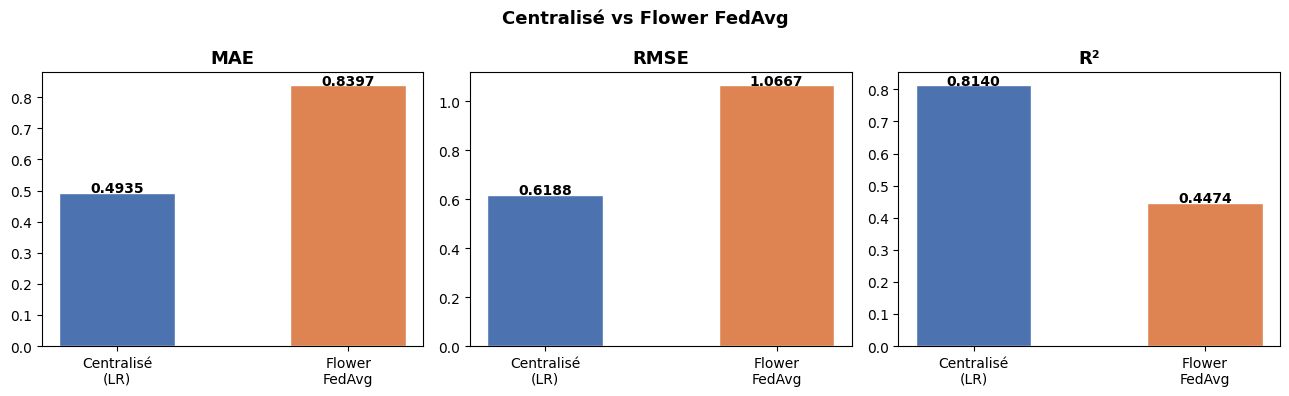

In [35]:
# Modèle centralisé de référence
modele_c = LinearRegression()
modele_c.fit(X_train_global, y_train_global)
y_pred_c = modele_c.predict(X_test_global)
mae_c    = mean_absolute_error(y_test_global, y_pred_c)
rmse_c   = np.sqrt(mean_squared_error(y_test_global, y_pred_c))
r2_c     = r2_score(y_test_global, y_pred_c)

final = df_hist.iloc[-1]

print("COMPARAISON FINALE")
print("=" * 55)
print(f"{'Modèle':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 55)
print(f"{'Centralisé (LR)':<25} {mae_c:>8.4f} {rmse_c:>8.4f} {r2_c:>8.4f}")
print(f"{'Flower FedAvg (FL)':<25} {final['mae']:>8.4f} {final['rmse']:>8.4f} {final['r2']:>8.4f}")
print("=" * 55)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
labels   = ['Centralisé\n(LR)', 'Flower\nFedAvg']
couleurs = ['#4C72B0', '#DD8452']

for ax, (m, val_c, val_fl) in zip(axes, [
    ('MAE',  mae_c,  final['mae']),
    ('RMSE', rmse_c, final['rmse']),
    ('R²',   r2_c,   final['r2']),
]):
    bars = ax.bar(labels, [val_c, val_fl], color=couleurs, edgecolor='white', width=0.5)
    ax.set_title(m, fontsize=13, fontweight='bold')
    for bar, val in zip(bars, [val_c, val_fl]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Centralisé vs Flower FedAvg', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Data/comparaison_centralise_flower.png', dpi=120, bbox_inches='tight')
plt.show()

## Cellule 9 — Conclusion

In [36]:
final  = df_hist.iloc[-1]
gap_r2 = abs(r2_c - final['r2'])

print("CONCLUSION")
print("=" * 55)
print(f"  Bibliothèque FL        : Flower {fl.__version__}")
print(f"  Objets Flower utilisés : NumPyClient, ndarrays_to_parameters,")
print(f"                           parameters_to_ndarrays, FedAvg")
print(f"  Clients (villes)       : {len(VILLES)} — {', '.join(VILLES)}")
print(f"  Rounds complétés       : {NUM_ROUNDS}")
print(f"  R² Flower FL           : {final['r2']:.4f}")
print(f"  R² Centralisé (LR)     : {r2_c:.4f}")
print(f"  Écart de performance   : {gap_r2:.4f}")
print(f"  Données jamais partagées entre villes : Vrai")
print("=" * 55)
if gap_r2 < 0.05:
    print(" Le modèle Flower FL approche le centralisé (écart < 0.05) — succès !")
else:
    print(f"Écart de {gap_r2:.4f} — augmente NUM_ROUNDS pour améliorer la convergence.")

CONCLUSION
  Bibliothèque FL        : Flower 1.31.0
  Objets Flower utilisés : NumPyClient, ndarrays_to_parameters,
                           parameters_to_ndarrays, FedAvg
  Clients (villes)       : 4 — Casablanca, Fes, Marrakech, Rabat
  Rounds complétés       : 10
  R² Flower FL           : 0.4474
  R² Centralisé (LR)     : 0.8140
  Écart de performance   : 0.3666
  Données jamais partagées entre villes : Vrai
Écart de 0.3666 — augmente NUM_ROUNDS pour améliorer la convergence.
